In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from utilities import replace_zeros_with_nan,create_features,impute_missing


In [21]:
df= pd.read_csv('diabetes.csv')


In [22]:
col=[c for c in df.columns if c != df.columns[0]]
print(col)

['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [23]:
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in zero_cols:
    count=(df[col]==0).sum()
    pct=count/len(df)*100
    print(f"{col} has {count} zero values which is {pct:.2f}% of the data")

Glucose has 5 zero values which is 0.65% of the data
BloodPressure has 35 zero values which is 4.56% of the data
SkinThickness has 227 zero values which is 29.56% of the data
Insulin has 374 zero values which is 48.70% of the data
BMI has 11 zero values which is 1.43% of the data


In [24]:
df_clean = replace_zeros_with_nan(df, zero_cols)

print("\nMissing values AFTER replacement:")
print(df_clean.isnull().sum())
print(f"\nTotal missing: {df_clean.isnull().sum().sum()}")


Missing values AFTER replacement:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Total missing: 652


In [25]:
for col in zero_cols:
    median_val = df_clean[col].median()
    print(f"  {col:25s}: {median_val:.1f}")

  Glucose                  : 117.0
  BloodPressure            : 72.0
  SkinThickness            : 29.0
  Insulin                  : 125.0
  BMI                      : 32.3


In [26]:
df_clean = impute_missing(df_clean, strategy="median")

print("Missing values AFTER imputation:")
print(df_clean.isnull().sum())
print(f"\nTotal missing: {df_clean.isnull().sum().sum()}")

Missing values AFTER imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Total missing: 0


In [27]:
df_missing = df_clean.copy()


print(df_missing.isnull().sum())
print(f"\nTotal missing: {df_missing.isnull().sum().sum()}")


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Total missing: 0


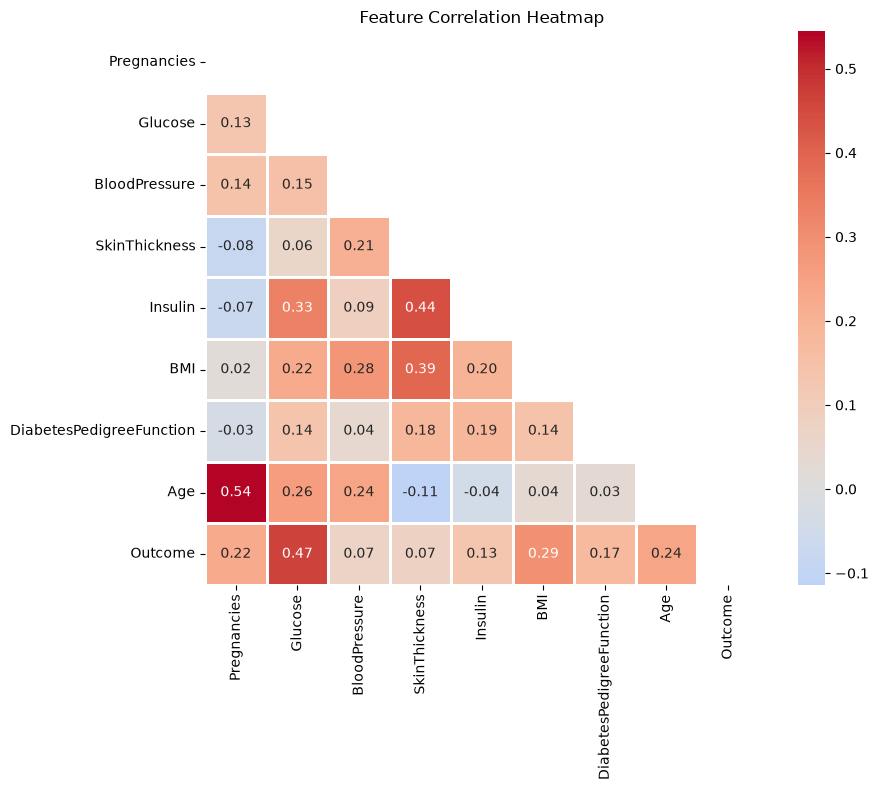

In [28]:
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=1)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [29]:

df_feat = create_features(df_clean)
print(set(df_feat.columns) - set(df_clean.columns))
print(df_feat.head())

{'AgeGroup', 'Insulin_Category', 'Glucose_Category', 'BMI_Category', 'BP_Category'}
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0    125.0  33.6   
1            1     85.0           66.0           29.0    125.0  26.6   
2            8    183.0           64.0           29.0    125.0  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome BMI_Category AgeGroup  \
0                     0.627   50        1        Obese      40s   
1                     0.351   31        0   Overweight      30s   
2                     0.672   32        1       Normal      30s   
3                     0.167   21        0   Overweight      20s   
4                     2.288   33        1        Obese      30s   

  Glucose_Category Insulin_Category BP_Category  
0         Diabetes           N

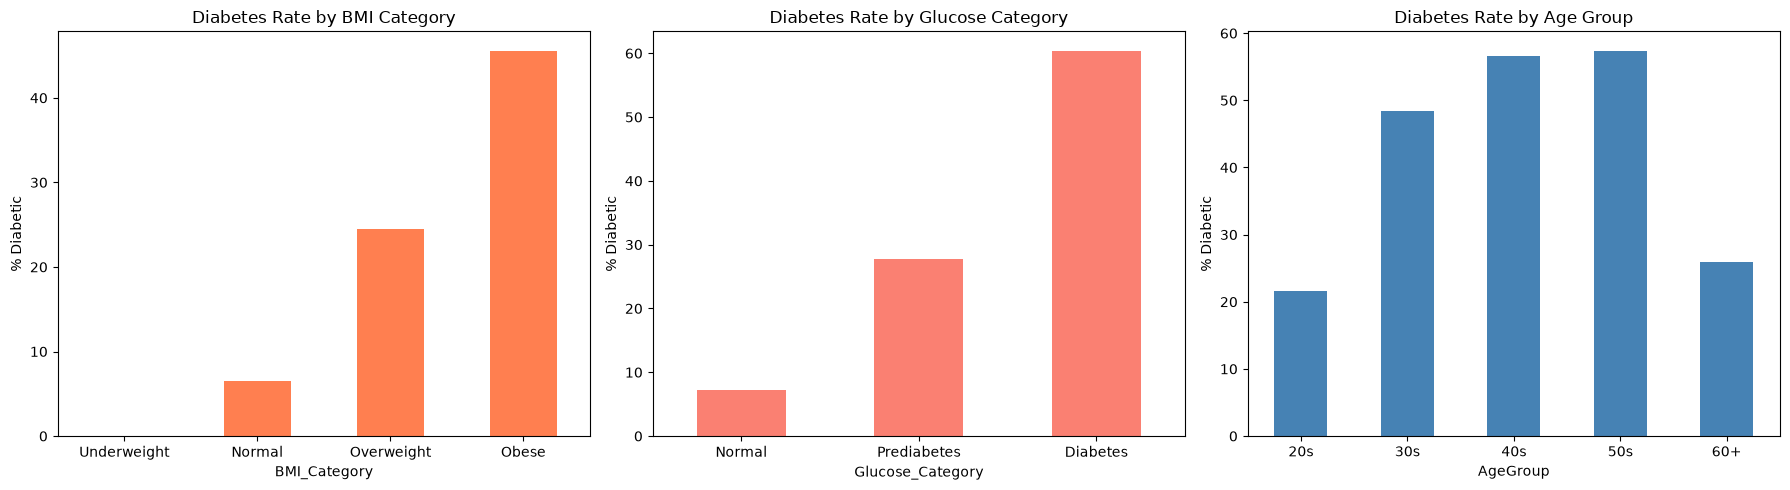

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
#diabetes rate by bmi
bmi_rate = df_feat.groupby("BMI_Category")["Outcome"].mean() * 100
bmi_rate.plot(kind="bar", color="coral", ax=axes[0])
axes[0].set_title("Diabetes Rate by BMI Category")
axes[0].set_ylabel("% Diabetic")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
#diabetes rate by glucose
glucose_rate = df_feat.groupby("Glucose_Category")["Outcome"].mean() * 100
glucose_rate.plot(kind="bar", color="salmon", ax=axes[1])
axes[1].set_title("Diabetes Rate by Glucose Category")
axes[1].set_ylabel("% Diabetic")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
#diabetes rate by age group 
age_rate = df_feat.groupby("AgeGroup")["Outcome"].mean() * 100
age_rate.plot(kind="bar", color="steelblue", ax=axes[2])
axes[2].set_title("Diabetes Rate by Age Group")
axes[2].set_ylabel("% Diabetic")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

In [31]:
print("Diabetes rate by BMI Category:")
for cat in bmi_rate.index:
    n = (df_feat["BMI_Category"] == cat).sum()
    print(f"  {str(cat):15s}: {bmi_rate[cat]:.1f}% (n={n})")

print("\nDiabetes rate by Glucose Category:")
for cat in glucose_rate.index:
    n = (df_feat["Glucose_Category"] == cat).sum()
    print(f"  {str(cat):15s}: {glucose_rate[cat]:.1f}% (n={n})")



Diabetes rate by BMI Category:
  Underweight    : 0.0% (n=4)
  Normal         : 6.5% (n=108)
  Overweight     : 24.4% (n=180)
  Obese          : 45.6% (n=476)

Diabetes rate by Glucose Category:
  Normal         : 7.3% (n=192)
  Prediabetes    : 27.8% (n=288)
  Diabetes       : 60.4% (n=288)


In [32]:
categorical_cols = ["BMI_Category", "AgeGroup", "Glucose_Category", "Insulin_Category", "BP_Category"]

df_encoded = pd.get_dummies(df_feat, columns=categorical_cols, drop_first=True)

print(f"Shape after encoding: {df_encoded.shape}")
print(f"\nColumns ({len(df_encoded.columns)}):")
for col in df_encoded.columns:
    print(f"  - {col} ({df_encoded[col].dtype})")

Shape after encoding: (768, 22)

Columns (22):
  - Pregnancies (int64)
  - Glucose (float64)
  - BloodPressure (float64)
  - SkinThickness (float64)
  - Insulin (float64)
  - BMI (float64)
  - DiabetesPedigreeFunction (float64)
  - Age (int64)
  - Outcome (int64)
  - BMI_Category_Normal (bool)
  - BMI_Category_Overweight (bool)
  - BMI_Category_Obese (bool)
  - AgeGroup_30s (bool)
  - AgeGroup_40s (bool)
  - AgeGroup_50s (bool)
  - AgeGroup_60+ (bool)
  - Glucose_Category_Prediabetes (bool)
  - Glucose_Category_Diabetes (bool)
  - Insulin_Category_Normal (bool)
  - Insulin_Category_High (bool)
  - BP_Category_High_Stage1 (bool)
  - BP_Category_High_Stage2 (bool)


In [33]:
print(f"Missing values: {df_encoded.isnull().sum().sum()}")
print(f"Final shape: {df_encoded.shape}")
df_encoded.head()

Missing values: 0
Final shape: (768, 22)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category_Normal,...,AgeGroup_30s,AgeGroup_40s,AgeGroup_50s,AgeGroup_60+,Glucose_Category_Prediabetes,Glucose_Category_Diabetes,Insulin_Category_Normal,Insulin_Category_High,BP_Category_High_Stage1,BP_Category_High_Stage2
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,False,...,False,True,False,False,False,True,True,False,False,False
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,False,...,True,False,False,False,False,False,True,False,False,False
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,True,...,True,False,False,False,False,True,True,False,False,False
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,False,...,False,False,False,False,False,False,True,False,False,False
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,False,...,True,False,False,False,False,True,False,True,False,False


In [34]:
df_encoded.to_csv("data/diabetes_cleaned.csv", index=False)
print("Saved cleaned dataset to data/diabetes_cleaned.csv")
print(f"  Rows   : {df_encoded.shape[0]}")
print(f"  Columns: {df_encoded.shape[1]}")

Saved cleaned dataset to data/diabetes_cleaned.csv
  Rows   : 768
  Columns: 22
